# Implementation of Poisson equation in 1D (Cartesian)

In [1]:
import logging
import numpy as np
from matplotlib import pyplot as plt
import multigrid_numba as multi
from scipy.special import erf
from timeit import default_timer
from numba import njit

In [2]:
@njit
def DirichletDirichlet(_grid, y, level):
    y[0] = 0
    y[-1] = 0 if level > 0 else 2


@njit
def NeumannDirichlet(_grid, y, level):
    y[0] = y[1]
    y[-1] = 0 if level > 0 else 2


@njit
def NeumannRobin(grid, y, _level):
    y[0] = y[1]
    y[-1] = y[-2] * grid[-2] / grid[-1]

In [3]:
def setup_grid(num_cells, x_start, x_end):

    grid = np.linspace(x_start, x_end, num_cells + 1)

    h  = grid[1] - grid[0]
    d2 = np.ones(num_cells + 1)
    d1 = np.zeros(num_cells + 1)
    d0 = np.zeros(num_cells + 1)
    src = np.sin(grid)
    mg = multi.Multigrid(
        num_cells,
        grid=grid,
        d0_coeff=d0,
        d1_coeff=d1,
        d2_coeff=d2,
        src=src,
        omega_sor=1,
        boundary=DirichletDirichlet,
        min_cells=20,
        tol=2.0e-9,
        initial_estimate=np.random.rand(*grid.shape),
        red_black_decouple=True,
        direct_restriction=False
    )

    mg.logger.handlers[0].setLevel(logging.DEBUG)
    mg.logger.setLevel(logging.DEBUG)
    return mg, grid

In [4]:
mg, grid = setup_grid(1024*4, 0.0, 20.0)
start = default_timer()
mg.solve_to_tolerance(smoothing_iters=100, max_vcycle_iters=100, subcycles=2)
end = default_timer()
print(f"solve took {end - start} seconds")
print(f"solve required {mg._iterations_required} iterations on parent grid")

err=np.float64(79485.82175840484) at it=0
Starting Vcycle
 restrict at 4096
 *  restrict at 2048
 *  *  restrict at 1024
 *  *  *  restrict at 512
 *  *  *  *  restrict at 256
 *  *  *  *  *  restrict at 128
 *  *  *  *  *  *  restrict at 64
 *  *  *  *  *  *  *  prolongate at 32
 *  *  *  *  *  *  restrict at 64
 *  *  *  *  *  *  *  prolongate at 32
 *  *  *  *  *  *  prolongate at 64
 *  *  *  *  *  restrict at 128
 *  *  *  *  *  *  restrict at 64
 *  *  *  *  *  *  *  prolongate at 32
 *  *  *  *  *  *  restrict at 64
 *  *  *  *  *  *  *  prolongate at 32
 *  *  *  *  *  *  prolongate at 64
 *  *  *  *  *  prolongate at 128
 *  *  *  *  restrict at 256
 *  *  *  *  *  restrict at 128
 *  *  *  *  *  *  restrict at 64
 *  *  *  *  *  *  *  prolongate at 32
 *  *  *  *  *  *  restrict at 64
 *  *  *  *  *  *  *  prolongate at 32
 *  *  *  *  *  *  prolongate at 64
 *  *  *  *  *  restrict at 128
 *  *  *  *  *  *  restrict at 64
 *  *  *  *  *  *  *  prolongate at 32
 *  *  *  *  *

solve took 0.8849609880126081 seconds
solve required 300 iterations on parent grid


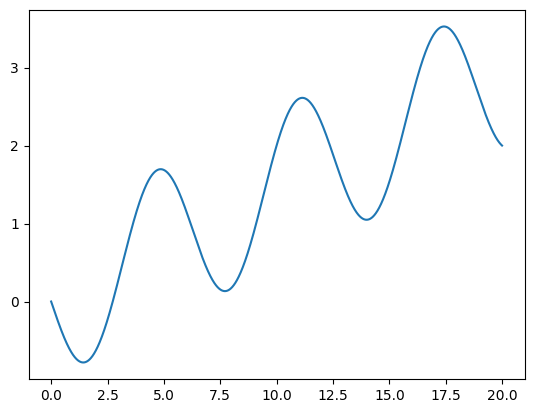

In [5]:
plt.plot(grid, mg.solution)

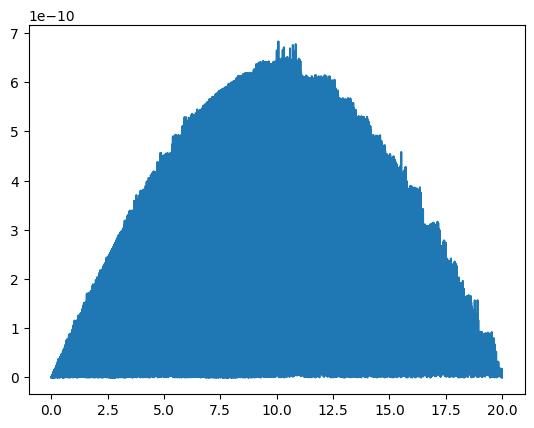

In [6]:
plt.plot(grid, np.abs(mg.defect))

In [7]:
def iterate_to_solution(mg, n_iters=100, tol=1.0e-10):
    mg.calculate_defect()
    err = np.linalg.norm(mg.defect, np.inf)
    while err > tol:
        mg.gauss_seidel_smoothing(n_iters=n_iters)
        mg.calculate_defect()
        err = np.linalg.norm(mg.defect, np.inf)
        print(err)

In [ ]:
mg, grid = setup_grid(1024*2, 0.0, 20.0)
start = default_timer()
iterate_to_solution(mg, n_iters=50000, tol=1.0e-9)
end = default_timer()
print(f"solve took {end - start} seconds")
print(f"solve required {mg._iterations_required} iterations on parent grid")